In [5]:
!pip install segmentation-models-pytorch

  Using cached segmentation_models_pytorch-0.3.3-py3-none-any.whl (106 kB)
  Using cached pretrainedmodels-0.7.4.tar.gz (58 kB)
  Preparing metadata (setup.py) ... done
  Using cached efficientnet_pytorch-0.7.1.tar.gz (21 kB)
  Preparing metadata (setup.py) ... done
  Using cached timm-0.9.2-py3-none-any.whl (2.2 MB)
  Using cached munch-4.0.0-py2.py3-none-any.whl (9.9 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvid

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
from torchvision.transforms import transforms
from tqdm import tqdm
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from segmentation_models_pytorch.losses import DiceLoss
import segmentation_models_pytorch as smp

In [44]:
from dataclasses import dataclass

@dataclass
class Args:
    model: str = 'unet'
    epochs: int = 40
    batch_size: int = 2
    learning_rate: float = 1e-5
    path_to_train_images: str = '/content/drive/MyDrive/segmentasi/train/mandible/images'
    path_to_train_masks: str = '/content/drive/MyDrive/segmentasi/train/mandible/masks'
    path_to_val_images: str = '/content/drive/MyDrive/segmentasi/val/mandible/images'
    path_to_val_masks: str = '/content/drive/MyDrive/segmentasi/val/mandible/masks'
    path_to_test_images: str = '/content/drive/MyDrive/segmentasi/test/mandible/images'
    path_to_test_masks: str = '/content/drive/MyDrive/segmentasi/test/mandible/masks'
    scale: float = 0.3

args = Args()

def pad(img, pad_size=32):
    height, width = img.shape[:2]
    if height % pad_size == 0 and width % pad_size == 0:
        return img
    else:
        new_height = ((height // pad_size) + 1) * pad_size
        new_width = ((width // pad_size) + 1) * pad_size
        padded_img = np.zeros((new_height, new_width), dtype=np.float32)
        padded_img[:height, :width] = img
        return padded_img

In [45]:
class MandibleDataset(Dataset):
    def __init__(self, path_to_images,path_to_masks, transform=None):
        self.path_to_images = path_to_images
        self.path_to_masks= path_to_masks
        self.transform = transform
        self.images = []
        self.masks = []
        for filename in os.listdir(self.path_to_images):
            img = cv2.imread(os.path.join(self.path_to_images, filename), 0)
            img=cv2.resize(img , (928,416))
            img=pad(img)
            img-=img.min()
            img = img.astype(np.float32) / img.max()
            self.images.append(img)
        i=-1
        for filename in os.listdir(self.path_to_masks):
            i+=1
            mask = cv2.imread(os.path.join(self.path_to_masks, filename), 0)
            mask=cv2.resize(mask , (928,416))
            mask=pad(mask)
            mask-=mask.min()
            mask = mask.astype(np.float32) / mask.max()
            mask=np.where(mask==np.unique(mask)[0],0,1)
            self.masks.append(mask)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]
        if self.transform is not None:
            image = self.transform(image).to(device).contiguous()
            mask = self.transform(mask).to(device).contiguous()
        return image, mask

In [46]:
def Dice(output,target,weight=None, eps=1e-5):
    target = target.float()
    if weight is None:
        num = 2 * (output * target).sum()
        den = output.sum() + target.sum() + eps
    return 1.0 - num/den

In [47]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    total_dice = 0
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data, target = data.to(device), target.to(device)
        target=target.squeeze(1).long()
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        total_dice +=Dice(output[:,0,:,:], target).item()
    train_loss /= len(train_loader)
    total_dice /= len(train_loader)
    return train_loss, total_dice

In [48]:
def validate(model, device, val_loader, criterion):
    model.eval()
    val_loss = 0
    total_dice = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            target=target.squeeze(1).long()
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            total_dice += Dice(output[:,0,:,:], target).item()
    val_loss /= len(val_loader)
    total_dice /= len(val_loader)
    return val_loss, total_dice

In [49]:
def plot_loss(train_loss, val_loss):
    plt.plot(train_loss, label='Train loss')
    plt.plot(val_loss, label='Validation loss')
    plt.title('Train and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_dice(train_dice, val_dice):
    plt.plot(train_dice, label='Train dice score')
    plt.plot(val_dice, label='Validation dice score')
    plt.title('Train and Validation Dice Score')
    plt.xlabel('Epoch')
    plt.ylabel('Dice score')
    plt.legend()
    plt.show()

<ipython-input-45-62a50dd7f791>:22: RuntimeWarning: invalid value encountered in divide
  mask = mask.astype(np.float32) / mask.max()


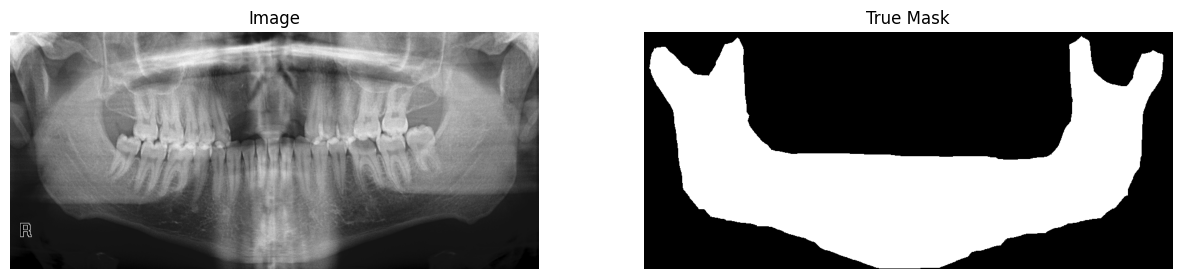

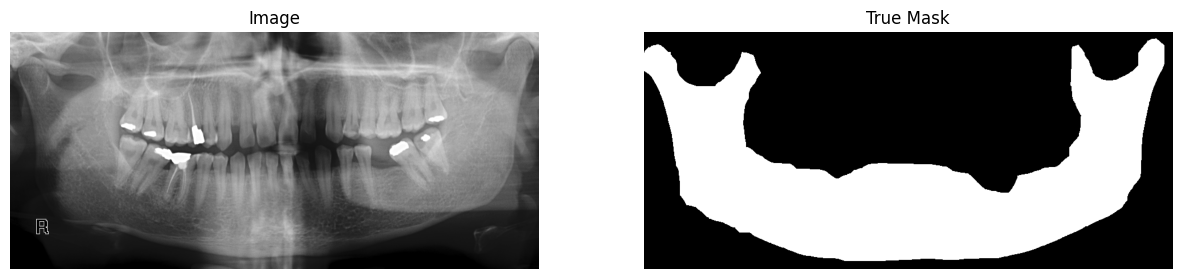

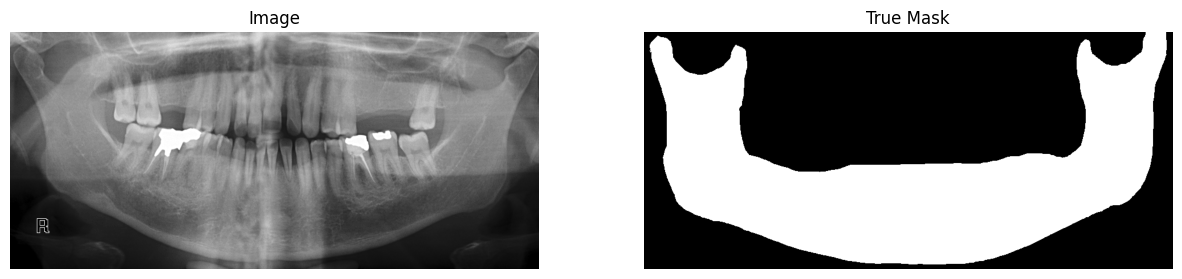

In [50]:
import matplotlib.pyplot as plt
import cv2
from torchvision.transforms import ToPILImage

def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Image', 'True Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(ToPILImage()(display_list[i].astype(np.float32)), cmap='gray')
        plt.axis('off')
    plt.show()

# Create dataset
train_dataset = MandibleDataset(args.path_to_train_images, args.path_to_train_masks)

# Display first 3 images and masks
for i in range(3):
    image, mask = train_dataset[i]
    image = torch.from_numpy(image).cpu().numpy()
    mask = torch.from_numpy(mask).cpu().numpy()
    display([image, mask])

In [51]:
def train_model(model, epochs, batch_size, learning_rate, device):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    criterion = DiceLoss('multiclass')
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    train_dataset = MandibleDataset(args.path_to_train_images, args.path_to_train_masks, transform=transform)
    val_dataset = MandibleDataset(args.path_to_val_images, args.path_to_val_masks, transform=transform)
    n_val = int(len(train_dataset) * 0.2)
    n_train = len(train_dataset) - n_val
    train_set, val_set = random_split(train_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(13))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, drop_last=True)  # Define val_loader here
    train_loss_list = []
    val_loss_list = []
    train_dice_list = []
    val_dice_list = []
    min_val_loss = 1000
    for epoch in range(epochs):
        print('Epoch {}/{}'.format(epoch + 1, epochs))
        train_loss, train_dice = train(model, device, train_loader, optimizer, criterion)
        print('Train loss: {:.6f}, Train dice score: {:.6f}'.format(train_loss, train_dice))
        val_loss, val_dice = validate(model, device, val_loader, criterion)
        print('Validation loss: {:.6f}, Validation dice score: {:.6f}'.format(val_loss, val_dice))
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_dice_list.append(train_dice)
        val_dice_list.append(val_dice)
        torch.save(model.state_dict(), 'checkpoints/{}_model_epoch{}.pth'.format(args.model, epoch + 1))
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(model.state_dict(), 'checkpoints/{}_model_best.pth'.format(args.model))
    plot_loss(train_loss_list, val_loss_list)
    plot_dice(train_dice_list, val_dice_list)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 83.0MB/s]
<ipython-input-45-62a50dd7f791>:22: RuntimeWarning: invalid value encountered in divide
  mask = mask.astype(np.float32) / mask.max()


Epoch 1/40


100%|██████████| 30/30 [00:04<00:00,  6.06it/s]


Train loss: 0.474550, Train dice score: 0.637364
Validation loss: 0.484093, Validation dice score: 0.585107
Epoch 2/40


100%|██████████| 30/30 [00:04<00:00,  6.11it/s]


...

Train loss: 0.335026, Train dice score: 0.887525
Validation loss: 0.386035, Validation dice score: 0.820182
Epoch 39/40


100%|██████████| 30/30 [00:04<00:00,  6.00it/s]


Train loss: 0.332697, Train dice score: 0.890683
Validation loss: 0.390653, Validation dice score: 0.827220
Epoch 40/40


100%|██████████| 30/30 [00:05<00:00,  5.96it/s]


Train loss: 0.332637, Train dice score: 0.891471
Validation loss: 0.385803, Validation dice score: 0.823211


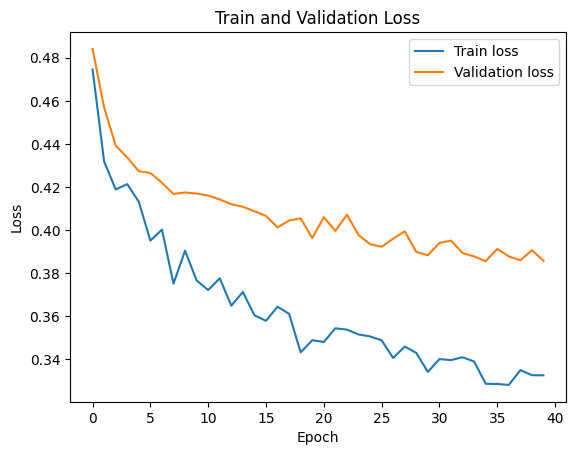

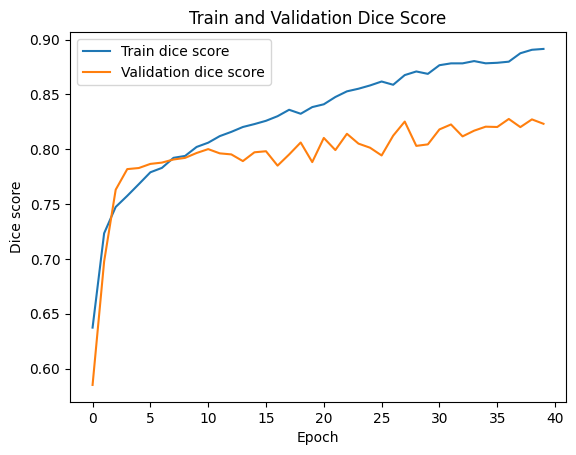

In [52]:
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if args.model=='unet':
        model = smp.Unet(
            encoder_name="resnet18",
            encoder_weights="imagenet",
            in_channels=1,
            classes=2,
            activation='sigmoid'
        )
    if args.model=='se_resnet':
        model = smp.Unet(
            encoder_name="se_resnet50",
            encoder_weights="imagenet",
            in_channels=1,
            classes=2,
            activation='sigmoid'
        )
    if args.model=='efficientnet':
        model = smp.Unet(
            encoder_name="efficientnet-b3",
            encoder_weights="imagenet",
            in_channels=1,
            classes=2,
            activation='sigmoid'
        )
    if args.model=='mobilenet':
        model = smp.Unet(
            encoder_name="mobilenet_v2",
            encoder_weights="imagenet",
            in_channels=1,
            classes=2,
            activation='sigmoid'
        )
    model = model.to(memory_format=torch.channels_last)
    model.to(device=device)
    if not os.path.exists('checkpoints'):
        os.mkdir('checkpoints')
    train_model(
        model=model,
        epochs=args.epochs,
        batch_size=args.batch_size,
        learning_rate=args.learning_rate,
        device=device)

In [53]:
import cv2
import torch
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

# Load the trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=1,
    classes=2,
    activation='sigmoid'
)
model.load_state_dict(torch.load('checkpoints/efficientnet_model_best.pth', map_location=device))
model.to(device=device)
model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 40, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          40, 40, kernel_size=(3, 3), stride=[1, 1], groups=40, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          40, 10, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          10, 40, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePaddi

In [54]:
def IoU(output, target, eps=1e-5):
    output = torch.sigmoid(output)  # apply sigmoid on the output
    output = (output > 0.5).float()  # apply a threshold to the output
    intersection = (output * target).sum()
    union = output.sum() + target.sum() - intersection + eps
    return intersection / union

def predict(image_path, mask_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (928, 416))
    img = img.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        prediction = model(img_tensor)
    mask_pred = prediction.squeeze().cpu().numpy()
    mask_pred = mask_pred / mask_pred.max() # normalize the mask here
    mask_pred = cv2.resize(mask_pred[0, :, :], (img.shape[1], img.shape[0]))  # resize the mask to the original image size

    # Load the true mask
    mask_true = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_true = cv2.resize(mask_true, (928, 416))
    mask_true = mask_true.astype(np.float32) / 255.0

    # Compute the IoU score
    iou_score = IoU(torch.from_numpy(mask_pred), torch.from_numpy(mask_true))

    return mask_pred, iou_score

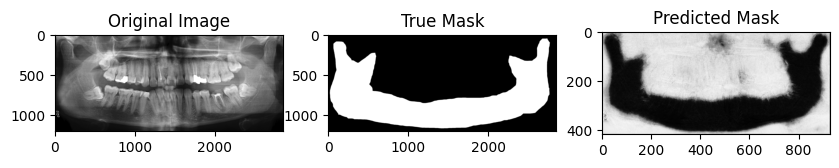

IoU score: 0.39163148403167725


In [55]:
# Perform prediction on an image
image_path = '/content/drive/MyDrive/segmentasi/test/mandible/images/91.png'
mask_path = '/content/drive/MyDrive/segmentasi/test/mandible/masks/91.png'
mask, iou_score = predict(image_path, mask_path)

# Display the original image and predicted mask
plt.figure(figsize=(10,5))
plt.subplot(2,3,1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title('Original Image')
plt.subplot(2,3,2)
plt.imshow(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title('True Mask')
plt.subplot(2,3,3)
plt.imshow(mask, cmap='gray')
plt.title('Predicted Mask')
plt.show()

# Print the IoU score
print(f"IoU score: {iou_score}")